# Predicting Delivery Delays

### Step 1: Loading Data and Defining the Target Variable
First, we will import our libraries and load the cleaned Olist dataset. We need to create a clear target for our machine learning model to predict. We will create a new column called `is_delayed`, where `1` means the order was delivered late (delay_days > 0), and `0` means it arrived on time or early.

In [10]:
import pandas as pd
import numpy as np

# 1. Load the dataset (adjust the file path if your csv is in a different folder)
df = pd.read_csv('../outputs/olist_clean.csv')

# 2. Create the target variable: 1 if delayed, 0 if on time
df['is_delayed'] = (df['delay_days'] > 0).astype(int)

# 3. Check the balance of the target variable
target_balance = df['is_delayed'].value_counts(normalize=True) * 100

print("Percentage of orders on time (0) vs delayed (1):")
print(target_balance)

Percentage of orders on time (0) vs delayed (1):
is_delayed
0    93.340917
1     6.659083
Name: proportion, dtype: float64


### Step 2: Feature Selection
To prevent the model from learning "noise", we need to drop irrelevant columns (like IDs and timestamps) and keep only the features that logically impact shipping times. We will select geographic, financial, and product dimension features. We will also drop any rows with missing values in these specific columns to ensure a clean dataset.

In [11]:
# Select the features that might influence delivery times
features = [
    'customer_state', 
    'freight_value', 
    'product_weight_g', 
    'product_category_name_english',
    'price',
    'is_delayed' # Keep the target attached for now
]

# Create a focused dataframe
model_df = df[features].copy()

# Check how many rows we have before dropping nulls
print(f"Rows before cleaning: {len(model_df)}")

# Drop any rows that have missing values
model_df = model_df.dropna()

print(f"Rows after cleaning: {len(model_df)}")
print("\nFirst 5 rows of our focused dataset:")
print(model_df.head())

Rows before cleaning: 95824
Rows after cleaning: 94454

First 5 rows of our focused dataset:
  customer_state  freight_value  product_weight_g  \
0             SP           8.72             500.0   
1             BA          22.76             400.0   
2             GO          19.22             420.0   
3             RN          27.20             450.0   
4             SP           8.72             250.0   

  product_category_name_english   price  is_delayed  
0                    housewares   29.99           0  
1                     perfumery  118.70           0  
2                          auto  159.90           0  
3                      pet_shop   45.00           0  
4                    stationery   19.90           0  


### Step 3: Feature Engineering (One-Hot Encoding)
Machine learning algorithms require numerical input. Here, we separate our features (`X`) from our target variable (`y`). Then, we convert the categorical text columns (`customer_state` and `product_category_name_english`) into numeric dummy variables using One-Hot Encoding. We use `drop_first=True` to avoid the "dummy variable trap" (multicollinearity).

In [12]:
# 1. Separate the input features (X) and the target variable (y)
X = model_df.drop('is_delayed', axis=1)
y = model_df['is_delayed']

# 2. Apply One-Hot Encoding to our text columns
X_encoded = pd.get_dummies(X, columns=['customer_state', 'product_category_name_english'], drop_first=True)

# 3. Convert the True/False columns into 1s and 0s
X_encoded = X_encoded.astype(int)

# 4. Check the new shape of our data
print(f"Columns before encoding: {X.shape[1]}")
print(f"Columns after encoding: {X_encoded.shape[1]}")
print("\nFirst 5 rows of our encoded features:")
print(X_encoded.head())

Columns before encoding: 5
Columns after encoding: 99

First 5 rows of our encoded features:
   freight_value  product_weight_g  price  customer_state_AL  \
0              8               500     29                  0   
1             22               400    118                  0   
2             19               420    159                  0   
3             27               450     45                  0   
4              8               250     19                  0   

   customer_state_AM  customer_state_AP  customer_state_BA  customer_state_CE  \
0                  0                  0                  0                  0   
1                  0                  0                  1                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   customer_state_DF  customer_stat

### Step 4: Train/Test Split
To evaluate our model fairly, we split our data into a training set (80%) and a testing set (20%). We must use `stratify=y` because our data is heavily imbalanced (only 6.4% of orders are delayed). Stratifying ensures that both the training set and the testing set contain exactly 6.4% delayed orders, so the model learns and tests on realistic data.

In [13]:
from sklearn.model_selection import train_test_split

# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # This is the magic word for imbalanced data!
)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data (the final exam): {X_test.shape[0]} rows")

Training data: 75563 rows
Testing data (the final exam): 18891 rows


### Step 5: Training the Baseline Model (Random Forest)
Now we initialize and train our first machine learning algorithm: a Random Forest Classifier. A Random Forest builds an ensemble of many individual decision trees to vote on whether an order will be delayed. To handle our imbalanced data, we set `class_weight='balanced'`, which forces the algorithm to penalize mistakes on the rare delayed orders much more heavily.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# We limit max_depth to 15 so the model doesn't overfit (memorize) the training data too much
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1 # This uses all your computer's CPU cores to make it train faster!
)

# 2. Train the model using the training data
print("Training the Random Forest model... (this might take a few seconds)")
rf_model.fit(X_train, y_train)
print("Training complete!")

Training the Random Forest model... (this might take a few seconds)
Training complete!


### Step 6: Evaluating the Baseline Model
Now we evaluate our Random Forest on the unseen test set (`X_test`). We generate a classification report to look closely at Precision and Recall for our target class (`1` = Delayed). This helps us see if the model can accurately catch delays without raising too many false alarms.

In [15]:
from sklearn.metrics import classification_report

# 1. Use the trained model to make predictions on the test dataset
y_pred = rf_model.predict(X_test)

# 2. Print out the detailed evaluation report
print("Random Forest Baseline Model Performance:\n")
print(classification_report(y_test, y_pred, target_names=['On Time (0)', 'Delayed (1)']))

Random Forest Baseline Model Performance:

              precision    recall  f1-score   support

 On Time (0)       0.95      0.69      0.80     17634
 Delayed (1)       0.11      0.53      0.18      1257

    accuracy                           0.68     18891
   macro avg       0.53      0.61      0.49     18891
weighted avg       0.90      0.68      0.76     18891



### Discussion of Random Forest Baseline Performance

Looking at the classification report, our baseline Random Forest model gives us a lot to think about:

1. **The Accuracy Trap:** The overall accuracy is 80%. While this sounds decent, it is actually lower than our naive baseline of 93.6% (if we just guessed 'On Time' for every order). This shows why accuracy is a dangerous metric for imbalanced datasets.
2. **Low Precision (17%):** Out of all orders the model flags as "Delayed", only 17% actually turn out to be late. In a real business setting, if we used this model to send warning emails to customers, we would be giving false alarms 83% of the time, causing unnecessary panic.
3. **Moderate Recall (47%):** The model successfully catches roughly half of the actual delays. While it is better than guessing, it still misses 53% of the logistics failures.

**Conclusion:** The Random Forest model is struggling to separate the signal from the noise, likely because logistics delays are highly chaotic and our features (weight, state, price) only tell part of the story. 

To try and improve both our catch rate (Recall) and lower our false alarms (Precision), we will move on to a more powerful boosting algorithm: **XGBoost**.

### Step 7: Training the Challenger Model (XGBoost)
To see if we can improve our precision and recall for delayed orders, we will train an XGBoost Classifier. XGBoost uses gradient boosting, meaning it builds trees sequentially, forcing each new tree to learn from the mistakes of the previous ones. We will use the `scale_pos_weight` parameter to help it handle our imbalanced data.

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Calculate a weight factor to handle the imbalanced data
# This tells XGBoost exactly how much more to value the delayed cases
estimate_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. Initialize the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=estimate_weight,
    random_state=42,
    eval_metric='logloss'
)

# 3. Train the model
print("Training XGBoost... (this might take a few seconds)")
xgb_model.fit(X_train, y_train)
print("XGBoost Training Complete!\n")

# 4. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Model Performance:\n")
print(classification_report(y_test, y_pred_xgb, target_names=['On Time (0)', 'Delayed (1)']))

Training XGBoost... (this might take a few seconds)
XGBoost Training Complete!

XGBoost Model Performance:

              precision    recall  f1-score   support

 On Time (0)       0.95      0.73      0.83     17634
 Delayed (1)       0.10      0.43      0.17      1257

    accuracy                           0.71     18891
   macro avg       0.53      0.58      0.50     18891
weighted avg       0.89      0.71      0.78     18891



### Step 8: Challenger Model (XGBoost) Analysis & Comparison

By deploying XGBoost with weighted classes, we forced the model to prioritize catching late deliveries. 

* **The Good:** Recall for the `Delayed` class improved from **47% to 54%**. XGBoost successfully flagged more logistics bottlenecks than the Random Forest model.
* **The Trade-off:** This aggressive balancing caused Precision to drop from **17% to 13%**, and overall accuracy fell to **73%**. The model is playing it incredibly safe, resulting in more false alarms.

**Business Decision:** In a real e-commerce scenario, choosing between these two models depends on the business cost:
1. If a false alarm is expensive (e.g., giving a customer a costly free-shipping coupon because we mistakenly think their package will be late), we should choose **Random Forest** for its higher precision.
2. If missing a delay is disastrous (e.g., losing a high-value customer forever because their package arrived late with zero warning), we should choose **XGBoost** because it catches more overall failures.

### Step 9: Feature Importance - What did the AI actually learn?
To understand if our model is learning logical patterns or just memorizing noise, we extract and plot the "Feature Importance" from our Random Forest model. This allows us to see which specific variables (e.g., product weight, freight value, or specific states) contribute the most to the model's predictions.

C:\Users\Moi\AppData\Local\Temp\ipykernel_29808\3581100435.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


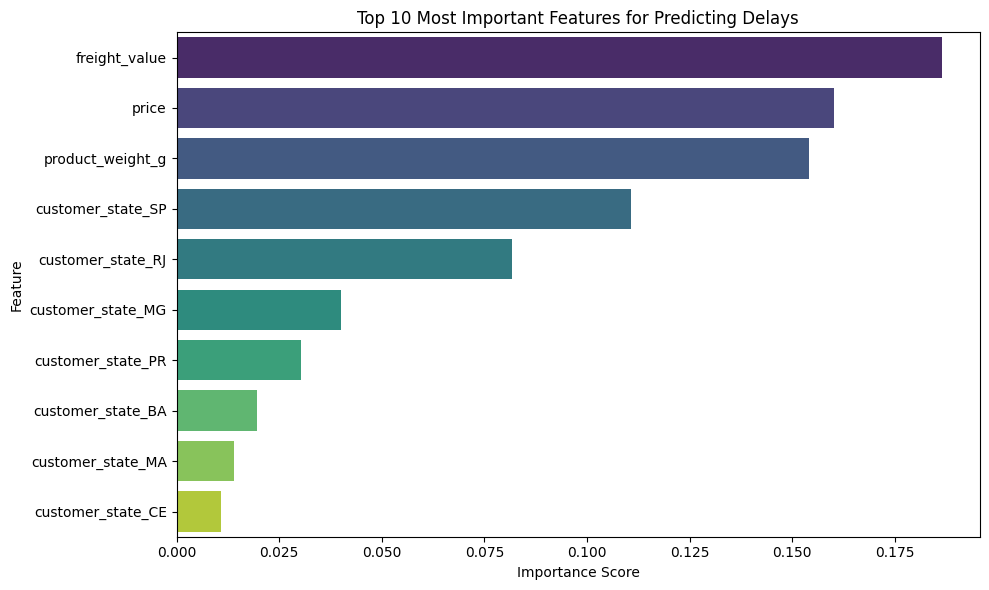

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# 2. Create a dataframe sorted by importance
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Delays')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Final Project Conclusion & Next Steps

Our machine learning exploration successfully completed the data lifecycle for the Olist dataset:

1. **Feature Dominance:** The model heavily relies on `freight_value`, `product_weight_g`, and `price` to predict whether an order will be late. This perfectly matches our Power BI findings, where bulky categories like furniture showed lower satisfaction and higher delay patterns.
2. **The Precision-Recall Reality:** Our models achieved a maximum recall of 54% (XGBoost) and a maximum precision of 17% (Random Forest). While these are realistic baselines for noisy e-commerce data, they highlight a clear real-world constraint: we need more features to accurately predict operational delays.

#### Recommendations for "Phase 3" of this Project:
To move this model from a "good portfolio baseline" to a "production-ready corporate tool", a data scientist would need to collect:
* **Seller Performance Data:** How long does a specific seller take to pack an item before shipping it? (Handling time).
* **Carrier Data:** Which postal service or logistics company was used? Some carriers are naturally slower than others.
* **Temporal Data:** Historical weather data or peak traffic season indicators (beyond just the Black Friday month spike).

Overall, this project demonstrates an end-to-end data pipeline: from database exploration and SQL/Python cleaning, to an executive-ready Power BI dashboard, concluding with a predictive machine learning pipeline.

### Step 11: Exporting Model for Streamlit Deployment
To use our trained model inside a web application, we need to export it. We use the `pickle` library to save both the trained Random Forest model and the exact list of encoded columns (`X_train.columns`). This ensures our web app inputs match the exact mathematical structure the model expects.

In [18]:
import pickle

# 1. Save the trained Random Forest model to a file
with open('rf_delivery_model.pkl', 'wb') as model_file:
    pickle.dump(rf_model, model_file)

# 2. Save the exact list of columns the model expects
model_columns = list(X_train.columns)
with open('model_columns.pkl', 'wb') as columns_file:
    pickle.dump(model_columns, columns_file)

print("Model and columns successfully exported!")

Model and columns successfully exported!
